**BackPropagation**

Objective for this notebook
 - Train a Neural Network to Solve the XOR Problem
 - Implement Backpropagation for Neural Network Training
 - Demonstrate the Use of Activation Functions
 - Understand the Learning Process Over Multiple Epochs
 - Demonstrate Weight and Bias Adjustments via Gradient Descent
 - Evaluate the Models Performance After Training
 - Monitor and Analyze the Training Process


In [ ]:
#!pip install numpy==1.26.4
#!pip install matplotlib==3.5.2

In [5]:
# Importing the required library
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

# Declare the network parameters & the weights

Define the network parameters such as
1. number of input neurons
2. hidden layer neurons
3. output neurons
4. learning rate
5. number of epochs

Also, Declare the weights for the neurons. The initial weights are taken as random numbers which are then optimized by the backpropagation algorithm inside a function parameter `initialize_network_parameters()`

In [15]:
def initialize_network_parameters():
    # Network parameters
    inputSize = 2      # Number of input neurons (x1, x2)
    hiddenSize = 2     # Number of hidden neurons
    outputSize = 1     # Number of output neurons
    lr = 0.01 #0.1           # Learning rate
    epochs = 1000000  #180000    # Number of training epochs

    # Initialize weights and biases randomly within the range [-1, 1]
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # Weights from input to hidden layer
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias for hidden layer
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Weights from hidden to output layer
    b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias for output layer

    return w1, b1, w2, b2, lr, epochs

## Training the Neural Network

The neural network works in 5 stages: 
1. Forward pass
    * The input **X** is multiplied by the weights **w1** and passed through the first layer, followed by the application of the sigmoid or ReLU activation function. This gives the output for the hidden layer.
    * The output of the hidden layer is then passed through the second set of weights **w2** to compute the final output. Again, a sigmoid activation function is used to generate the final output **a2**.
    
2. Error calculation
    * The error is computed as the difference between the expected output **(d)** and the actual output **(a2)**.
3. Backward pass
    * **Output Layer**: The derivative of the sigmoid activation function is applied to the error, producing the gradient for the output layer **(da2)**. This is used to calculate how much the weights in the output layer need to be adjusted.
    * **Hidden Layer**: The error is then propagated backward to the hidden layer. The gradient at the hidden layer **(da1)** is computed by taking the dot product of the transpose of the weights **(w2.T)** and the gradient from the output layer. The derivative of the activation function (sigmoid or ReLU) is used to adjust this error.
4. Weights and bias updates
    * After computing the **gradients (dz1, dz2)**, the **weights (w1, w2)** and **biases (b1, b2)** are updated using the **learning rate (lr)** and **the gradients**. The updates are done to minimize the error and improve the model’s predictions.
5. Training:
    * This entire process is repeated over many iterations **(epochs)**. During each epoch, the model adjusts its weights and biases to reduce the error. Over time, the network learns to approximate the XOR function.
Forward Pass:


In [16]:
# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Average error: 0.33795
Epoch: 19999, Average error: 0.14277
Epoch: 29999, Average error: 0.08099
Epoch: 39999, Average error: 0.05896
Epoch: 49999, Average error: 0.04767
Epoch: 59999, Average error: 0.04071
Epoch: 69999, Average error: 0.03593
Epoch: 79999, Average error: 0.03241
Epoch: 89999, Average error: 0.02970
Epoch: 99999, Average error: 0.02752
Epoch: 109999, Average error: 0.02574
Epoch: 119999, Average error: 0.02424
Epoch: 129999, Average error: 0.02296
Epoch: 139999, Average error: 0.02186
Epoch: 149999, Average error: 0.02089
Epoch: 159999, Average error: 0.02003
Epoch: 169999, Average error: 0.01926
Epoch: 179999, Average error: 0.01857
Epoch: 189999, Average error: 0.01795
Epoch: 199999, Average error: 0.01738
Epoch: 209999, Average error: 0.01686
Epoch: 219999, Average error: 0.01638
Epoch: 229999, Average error: 0.01593
Epoch: 239999, Average error: 0.01552
Epoch: 249999, Average error: 0.01514
Epoch: 259999, Average error: 0.01479
Epoch: 269999, Average 

In [17]:
# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

Final output after training: [[0.00126689 0.00828186 0.00830288 0.99054703]]
Ground truth [0 0 0 1]
Error after training: [[-0.00126689 -0.00828187 -0.00830289  0.00945298]]
Average error: 0.00683


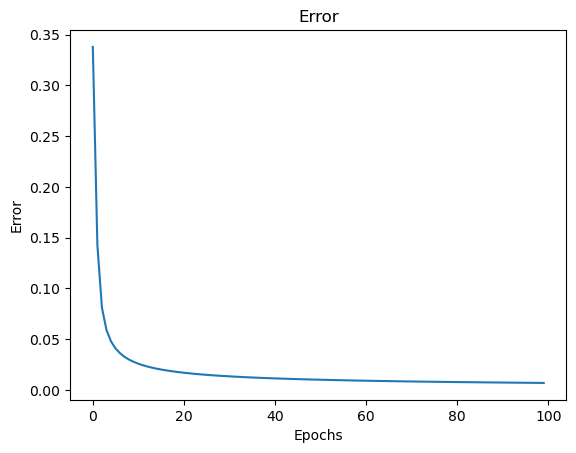

In [18]:
# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Implement backpropagation for **AND problem** using similar input as used for XOR problem above and plot the error

In [12]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for AND

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Average error: 0.02591
Epoch: 19999, Average error: 0.01633
Epoch: 29999, Average error: 0.01269
Epoch: 39999, Average error: 0.01066
Epoch: 49999, Average error: 0.00934
Epoch: 59999, Average error: 0.00839
Epoch: 69999, Average error: 0.00768
Epoch: 79999, Average error: 0.00711
Epoch: 89999, Average error: 0.00665
Epoch: 99999, Average error: 0.00626
Epoch: 109999, Average error: 0.00593
Epoch: 119999, Average error: 0.00565
Epoch: 129999, Average error: 0.00540
Epoch: 139999, Average error: 0.00518
Epoch: 149999, Average error: 0.00498
Epoch: 159999, Average error: 0.00481
Epoch: 169999, Average error: 0.00465
Epoch: 179999, Average error: 0.00450


In [13]:
# Testing the trained network for AND 
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

Final output after training: [[4.56469452e-04 5.44604364e-03 5.04687022e-03 9.92945540e-01]]
Ground truth [0 0 0 1]
Error after training: [[-0.00045647 -0.00544606 -0.00504689  0.00705448]]
Average error: 0.00450


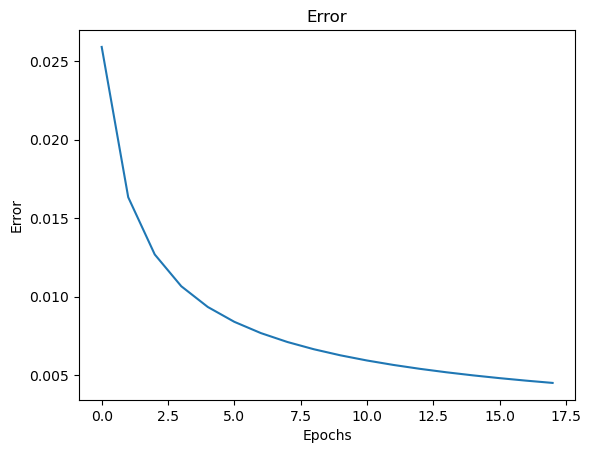

In [14]:
# Plot error for AND
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()
